# Example: Spectral-Assisted LAP Tracking Analysis

This notebook demonstrates the spectral-assisted LAP (Linear Assignment Problem) tracker
for linking single-molecule localisations across frames using both spatial proximity
and colour (spectral) information.

**Input:** `.h5` localisation database produced by `SR_Functions.fit_SM_data()` or similar,
containing columns: `frame, xc, yc, s_x, s_y, bg_B, bg_G, bg_R, A_B, A_G, A_R, chi_sqr`
and corresponding error columns.

**Algorithm:** Jaqaman et al. (2008) Nat. Methods 5, 695-702, extended with spectral
distance in normalised RGB space.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys

sys.path.append("../..")

from src import IOFunctions
IO = IOFunctions.IO_Functions()

from src import SM_extractionfunctions
SM_E = SM_extractionfunctions.extract_SMs()

from src import HelperFunctions
H_F = HelperFunctions.Helper_Functions()

from src import PlottingBase
plotter = PlottingBase.PublicationPlotter()

from copy import copy

import DriftCorrectionFunctions as DCF


In [ ]:
import sys
import tifffile
sys.path.insert(0, "/home/jsb92/Documents/pyDiffusion_LeeLab/src")
from CVE_Functions import CVE as CVE_class
cve = CVE_class()
from MSDFunctions import MSD as MSD_class
msd = MSD_class()
from sklearn.cluster import KMeans


## 1. Load localisation data

Point `data_folder` at a directory containing `.h5` localisation files
produced by `fit_SM_data()`. Each file should contain one FOV of tracking data.

In [5]:
# --- USER: Set your data path here ---
data_folder = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260324_LipidBilayers/AF488ICAM1_AF555CD58_JF646UCHT1"

localisation_files = H_F.file_search(data_folder, ".h5", "undrifted")
print(f"Found {len(localisation_files)} localisation file(s)")

Found 31 localisation file(s)


In [6]:
metadata_files = H_F.file_search(data_folder, "metadata", "")
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

## 2. Quality filter parameters

These are passed to `filter_quality_localisations()` internally.

In [9]:
# Quality filters
chi_val = 2.0
max_localisation_error = 1.5   # pixels
max_colour_error = 0.15
min_photons = 100
max_photons = 1e6

# Linking parameters
max_distance = 8.0    # pixels — maximum spatial jump per frame. This corresponds to half a micron in 50 ms
max_dark_time = 3     # frames — maximum gap before track is terminated

# Spectral weighting
w_spatial = 1.0       # weight for spatial cost term
w_spectral = 1.0      # weight for spectral cost term
spectral_tol = 0.15   # normalisation scale for spectral distance

## 3. Run spectral LAP linking — all FOVs

Loop over every localisation file, link each independently, tag with the full file path
as `fov_name`, offset `molecular_index` to be globally unique, then concatenate into
combined single-molecule (`sm_db_all`) and single-frame (`sf_db_all`) databases.

In [10]:
all_sm = []
all_sf = []
running_idx_offset = 0
min_frames = 10

for f in localisation_files:
    fov_name = f  # full path as unique FOV identifier
    print(f"Processing: {os.path.basename(f)}")

    loc_data = pd.read_hdf(f)

    sm, sf = SM_E.extract_single_molecules_spectral_lap(
        loc_data.copy(),
        max_distance=max_distance,
        max_dark_time=max_dark_time,
        w_spatial=w_spatial,
        w_spectral=w_spectral,
        spectral_tol=spectral_tol,
        chi_val=chi_val,
        max_localisation_error=max_localisation_error,
        max_colour_error=max_colour_error,
        min_photons=min_photons,
        max_photons=max_photons,
        verbose=False,
    )

    sm = sm[sm['frames'] > min_frames].copy()
    sf = sf[sf['molecular_index'].isin(sm['molecular_index'])].copy()

    sm['molecular_index'] += running_idx_offset
    sf['molecular_index'] += running_idx_offset
    sm['fov_name'] = fov_name
    sf['fov_name'] = fov_name

    running_idx_offset = int(sm['molecular_index'].max()) + 1

    all_sm.append(sm)
    all_sf.append(sf)
    print(f"  -> {len(sm)} molecules")

sm_db = pd.concat(all_sm, ignore_index=True)
sf_db = pd.concat(all_sf, ignore_index=True)

print(f"\nTotal: {len(sm_db)} molecules from {len(localisation_files)} FOVs")

Processing: 4banddichroic_NF_1_MMStack_Default_undrifted.h5
  -> 39 molecules
Processing: 4banddichroic_NF_2_MMStack_Default_undrifted.h5
  -> 36 molecules
Processing: 4banddichroic_NF_3_MMStack_Default_undrifted.h5
  -> 107 molecules
Processing: 4banddichroic_NF_4_MMStack_Default_undrifted.h5
  -> 92 molecules
Processing: 4banddichroic_NF_5_MMStack_Default_undrifted.h5
  -> 57 molecules
Processing: 4banddichroic_NF_6_MMStack_Default_undrifted.h5
  -> 47 molecules
Processing: 4banddichroic_NF_1_MMStack_Default_undrifted.h5
  -> 29 molecules
Processing: 4banddichroic_NF_2_MMStack_Default_undrifted.h5
  -> 43 molecules
Processing: 4banddichroic_NF_3_MMStack_Default_undrifted.h5
  -> 91 molecules
Processing: 4banddichroic_NF_4_MMStack_Default_undrifted.h5
  -> 55 molecules
Processing: 4banddichroic_NF_5_MMStack_Default_undrifted.h5
  -> 58 molecules
Processing: 4banddichroic_NF_6_MMStack_Default_undrifted.h5
  -> 36 molecules
Processing: 4banddichroic_NF_1_MMStack_Default_undrifted.h5
  -

## 4. Inspect the results

/tmp/ipykernel_2392343/3732874691.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


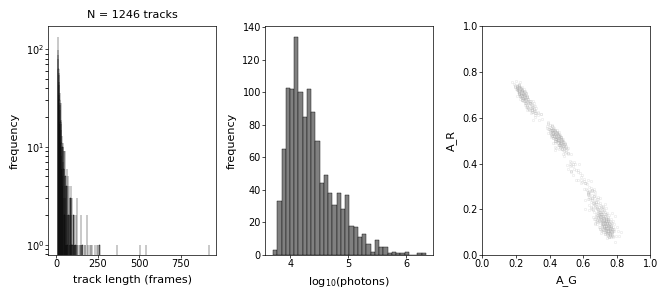

In [11]:
# Track length distribution
track_lengths = sf_db.groupby("molecular_index").size()

fig, axs = plotter.two_column_plot(ncols=3)

# Track lengths
bins = np.arange(0.5, track_lengths.max() + 1.5, 1)
axs[0].hist(track_lengths, bins=bins, color="gray", edgecolor="black", linewidth=0.3)
axs[0].set_xlabel("track length (frames)")
axs[0].set_ylabel("frequency")
axs[0].set_yscale('log')
axs[0].set_title(f"N = {len(track_lengths)} tracks")

# Photons per molecule
bins_ph = np.histogram_bin_edges(np.log10(sm_db["photons"].to_numpy()), "sqrt")
axs[1].hist(np.log10(sm_db["photons"]), bins=bins_ph, color="gray", edgecolor="black", linewidth=0.3)
axs[1].set_xlabel(r"log$_{10}$(photons)")
axs[1].set_ylabel("frequency")

# Colour distribution (per molecule)
axs[2].scatter(sm_db["A_G"], sm_db["A_R"], s=3, alpha=0.25, c="white", edgecolors="gray", linewidth=0.3)
axs[2].set_xlabel("A_G")
axs[2].set_ylabel("A_R")
axs[2].set_xlim([0, 1])
axs[2].set_ylim([0, 1])

plt.tight_layout()
#plt.savefig('For_Dan.svg', dpi=600, format='svg')
plt.show()

## 5. Visualise trajectories

Plot spatial trajectories coloured by their average RGB values.

In [12]:
len(sm_db)

1246

## 9. Colour clustering

Assign each molecule to one of three colour clusters using KMeans on normalised
(A_R, A_G, A_B). Clusters are ordered by mean A_R so that:
- **Cluster 0** → lowest A_R (AF488, blue channel dominant)
- **Cluster 1** → intermediate (AF555, green channel dominant)
- **Cluster 2** → highest A_R (JF646, red channel dominant)

The sanity-check scatter (A_R vs A_G) should show three well-separated clouds.

In [13]:
# Normalise colour fractions to sum to 1 per molecule
colour_feat = sm_db[["A_R", "A_G", "A_B"]].to_numpy().astype(float)
row_sums = colour_feat.sum(axis=1, keepdims=True)
colour_norm = colour_feat / np.where(row_sums > 0, row_sums, 1.0)

# Fit KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(colour_norm)

# Order clusters by ascending mean A_R: 0 = bluest (AF488), 2 = reddest (JF646)
mean_AR = [colour_norm[labels == k, 0].mean() for k in range(3)]
order = np.argsort(mean_AR)   # indices of clusters sorted low→high A_R
remap = {int(old): int(new) for new, old in enumerate(order)}
sm_db["colour_cluster"] = np.array([remap[l] for l in labels], dtype=int)

# Propagate cluster labels to sf_db via molecular_index
cluster_map = sm_db.set_index("molecular_index")["colour_cluster"]
sf_db["colour_cluster"] = sf_db["molecular_index"].map(cluster_map)

print("Molecules per cluster:")
print(sm_db["colour_cluster"].value_counts().sort_index())

Molecules per cluster:
colour_cluster
0    499
1    369
2    378
Name: count, dtype: int64


/home/jsb92/Documents/pyBayerSMLM/notebooks/tracking/../../src/PlottingBase.py:2111: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


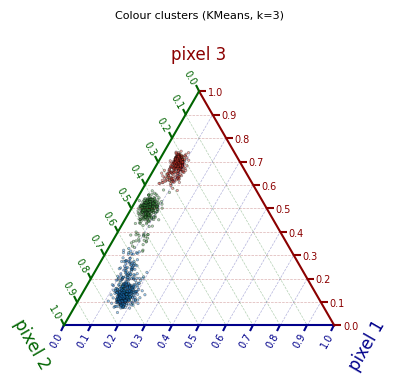

In [16]:
cluster_colors = ["#2196F3", "#4CAF50", "#F44336"]   # blue, green, red
cluster_names  = ["AF488", "AF555", "JF646"]

# Build per-molecule RGBA colour array for ternary plot
import matplotlib.colors as mcolors
rgba_colors = np.array([mcolors.to_rgba(cluster_colors[k])
                        for k in sm_db["colour_cluster"]])

# Ternary sanity-check: colour_norm already computed in previous cell
fig, ax = plotter.create_ternary_plot(
    colour_norm[:, 0], colour_norm[:, 1], colour_norm[:, 2],
    colors=rgba_colors, marker_size=3, marker_alpha=0.4,
    title="Colour clusters (KMeans, k=3)",
    labels={"R": "pixel 3", "G": "pixel 2", "B": "pixel 1"},
    figsize=(4, 4), rasterized=True,
)
folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks/Tracking'
fig.savefig(os.path.join(folder, 'Colour_Clusters.svg'), dpi=600, format='svg',
            bbox_inches='tight')
plt.show()

/tmp/ipykernel_2392343/4175328340.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  color = cluster_colors[int(sm_db[sm_db['molecular_index'] == mol_idx]['colour_cluster'].values)]
/tmp/ipykernel_2392343/4175328340.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


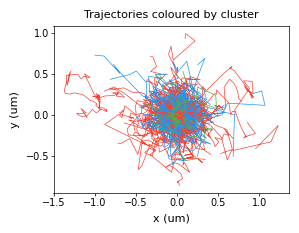

In [17]:
fig, ax = plotter.create_figure(figsize=(3, 3))
cluster_colors = ["#2196F3", "#4CAF50", "#F44336"]   # blue, green, red

pixel_size = 69
for mol_idx in np.unique(sm_db["molecular_index"].values):
    randx = np.random.uniform(low=0, high=1)*0
    randy = np.random.uniform(low=0, high=1)*0
    track = sf_db[sf_db["molecular_index"] == mol_idx].sort_values("frame")
    if len(track) < 11:
        continue
    color = cluster_colors[int(sm_db[sm_db['molecular_index'] == mol_idx]['colour_cluster'].values)]
    # Use track colour as line colour
    ax.plot(0.069*(randx + track["xc"]-np.median(track["xc"])), 0.069*(randy + track["yc"]-np.median(track["yc"])), lw=0.5, alpha=1, color=color)

ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_aspect("equal")
ax.set_title("Trajectories coloured by cluster")
#ax.set_xlim([500, 550])
#ax.set_ylim([50, 100])
#ax.set_xlim([-0.1, 3.6])
#ax.set_ylim([-0.1, 3.6])
plt.tight_layout()
plt.show()

In [ ]:
def gen_MSD(XY):
    """Compute MSD from 2D trajectory using the FFT method.

    Args:
        XY: (2, N) array — row 0 = x, row 1 = y (any units)

    Returns:
        MSD values for lag times 1..N-1 (same units squared)
    """
    r = XY.T  # msd_fft expects shape (N, n_d)
    return msd.msd_fft(r)


In [ ]:
cluster_colors = ["#2196F3", "#4CAF50", "#F44336"]   # blue, green, red

pixel_size_um = 0.069   # µm per pixel
frame_time_s  = 0.5    # seconds per frame
min_msd_len   = 11     # minimum track length

fig, ax = plotter.one_column_plot(npanels=1, height=2, width=2)

for _, row in sm_db.iterrows():
    mol_idx = row["molecular_index"]
    track = sf_db[sf_db["molecular_index"] == mol_idx].sort_values("frame")
    if len(track) < min_msd_len:
        continue
    color = cluster_colors[int(row["colour_cluster"])]
    x_um = track["xc"].values * pixel_size_um
    y_um = track["yc"].values * pixel_size_um
    msd_vals = gen_MSD(np.vstack([x_um, y_um]))
    lag_times = np.arange(1, len(msd_vals) + 1) * frame_time_s
    ax.plot(lag_times, msd_vals, color=color, alpha=0.1,
            linewidth=0.5, rasterized=True)

ax.set_xlabel("lag time (s)")
ax.set_ylabel("MSD (µm²)")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_title("MSD per molecule")
plt.tight_layout()
folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks/Tracking'
plt.savefig(os.path.join(folder, 'MSD_per_molecule.svg'), dpi=600,
            format='svg', bbox_inches='tight')
plt.show()

In [ ]:
track['xc']

## 10. CVE diffusion coefficient per molecule

For each molecule with at least `min_frames_cve` localisations, estimate the
2D diffusion coefficient using the Covariance-Based Estimator (CVE) of Vestergaard
et al. (Phys. Rev. E 2014, 89, 022726). Positions are converted to nm before passing
to the estimator so D comes out in nm² s⁻¹, then converted to μm² s⁻¹.

Tracks with frame gaps are treated as uniformly sampled — a valid approximation when
`max_dark_time` is small relative to track length.

In [39]:
# --- USER: set physical parameters ---
pixel_size_nm = 69.0   # nm per pixel
frame_time_s  = 0.5    # seconds per frame
R_blur        = 1.0 / 6  # motion blur coefficient (camera exposure / frame time)
min_frames_cve = 5    # minimum track length for a CVE estimate

cve_records = []
for _, row in sm_db.iterrows():
    track = sf_db[sf_db["molecular_index"] == row["molecular_index"]].sort_values("frame")
    if len(track) < min_frames_cve:
        continue

    x_nm = track["xc"].to_numpy() * pixel_size_nm
    y_nm = track["yc"].to_numpy() * pixel_size_nm
    coords = np.column_stack([x_nm, y_nm])   # shape (N, 2)

    D, sigma = msd.DSigma2_OLSF(coords, frame_time_s, R=R_blur, n_d=2,
                               min_points=min_frames_cve)
    cve_records.append({
        "molecular_index": row["molecular_index"],
        "D_nm2_s":         D,
        "sigma_nm":        sigma,
        "colour_cluster":  row["colour_cluster"],
        "fov_name":        row["fov_name"],
        "frames":          row["frames"],
        "photons":         row["photons"],
    })

cve_df = pd.DataFrame(cve_records)
cve_df["D_um2_s"] = cve_df["D_nm2_s"] / 1e6

# Keep physically plausible values (0 < D < 100 μm²/s)
cve_df = cve_df[(cve_df["D_um2_s"] > 0) & (cve_df["D_um2_s"] < 1000)].copy()

print(f"MSD estimates: {len(cve_df)} molecules")
print(cve_df.groupby("colour_cluster")["D_um2_s"].describe().round(4))

OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations
OLSF did not converge in 100 iterations


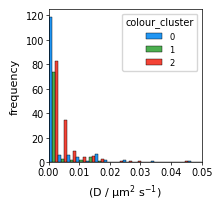

In [42]:
cluster_colors = ["#2196F3", "#4CAF50", "#F44336"]   # blue, green, red
cluster_names  = ["AF488", "AF555", "JF646"]

fig, axs = plotter.one_column_plot(npanels=1, height=2, width=2)

bins = np.histogram_bin_edges(cve_df['D_um2_s'], 'scott')
import seaborn as sns

# Filter positive D values and create a long‑form DataFrame
df_plot = cve_df[['colour_cluster', 'D_um2_s']].dropna()
df_plot = df_plot[df_plot['D_um2_s'] > 0]

sns.histplot(data=df_plot, x='D_um2_s', hue='colour_cluster',
             bins=bins, multiple='dodge', edgecolor='black', linewidth=0.3,
             palette=cluster_colors, alpha=1, ax=axs)
axs.set_xlim([0, 0.05])
axs.set_xlabel(r"(D / μm$^2$ s$^{-1}$)")
axs.set_ylabel("frequency")
folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks/Tracking'
plt.savefig(os.path.join(folder, 'Clustered_MSD.svg'), dpi=600, format='svg')
plt.show()

## 11. Raw image overlay

Load the raw TIFF for one FOV, max-project the first 100 frames, and overlay
single-molecule positions as open circles coloured by their `colour_cluster` identity.
Change `fov_index` to inspect a different field of view.

In [ ]:
# --- USER: set FOV to display (index into localisation_files) ---
fov_index = 2
fov_to_show = localisation_files[fov_index]

# Infer TIFF path from .h5 path (try .ome.tif then .tif)
tiff_path = fov_to_show.replace("_undrifted.h5", ".ome.tif")
if not os.path.exists(tiff_path):
    tiff_path = fov_to_show.replace("_undrifted.h5", ".tif")

# Load and max-project first 100 frames
with tifffile.TiffFile(tiff_path) as tif:
    n_pages = len(tif.pages)
    stack = tif.asarray(key=range(min(100, n_pages)))

img = stack.max(axis=0) if stack.ndim == 3 else stack

# Localisations and tracks for this FOV only
sm_fov = sm_db[sm_db["fov_name"] == fov_to_show]
sf_fov = sf_db[sf_db["fov_name"] == fov_to_show]

cluster_colors = ["#2196F3", "#4CAF50", "#F44336"]   # blue, green, red
cluster_names  = ["AF488", "AF555", "JF646"]

fig, ax = plotter.create_figure(figsize=(2, 2))
ax = plotter.image_plot(ax, img, cmap="gray",
          vmin=np.percentile(img, 1), vmax=np.percentile(img, 99.9),
          origin="upper", scalebarsize=1000, scalebarlabel='1 μm',
          scalebar=True, pixelsize=69)
ax = ax[0]

# Overlay tracks as lines, then median positions as open circles
for k in range(3):
    mol_subset = sm_fov[sm_fov["colour_cluster"] == k]
    for mol_idx in mol_subset["molecular_index"].values:
        track = sf_fov[sf_fov["molecular_index"] == mol_idx].sort_values("frame")
        ax.plot(track["xc"].values, track["yc"].values,
                color=cluster_colors[k], linewidth=0.5, alpha=0.5, zorder=1)
    # Median positions as open circles on top
    ax.scatter(mol_subset["xc"], mol_subset["yc"], s=75,
               facecolors="none", edgecolors=cluster_colors[k],
               linewidths=1, label=f"{cluster_names[k]}", zorder=2)

ax.legend(loc="best", fontsize=6)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_xlim([190, 290])
ax.set_ylim([150, 250])
plt.tight_layout()
folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks/Tracking'
plt.savefig(os.path.join(folder, 'Individual_Molecules_Labelled.svg'),
            dpi=600, format='svg', bbox_inches='tight')
plt.show()

## 8. Save results

In [ ]:
# Save combined single-molecule and single-frame databases
output_folder = data_folder

sm_db.to_hdf(
    os.path.join(output_folder, "spectral_lap_single_molecules.h5"),
    key="data", format="table",
)
sf_db.to_hdf(
    os.path.join(output_folder, "spectral_lap_single_frames.h5"),
    key="data", format="table",
)

print(f"Saved to {output_folder}")
print(f"  spectral_lap_single_molecules.h5  ({len(sm_db)} molecules from {sm_db['fov_name'].nunique()} FOVs)")
print(f"  spectral_lap_single_frames.h5     ({len(sf_db)} localisations)")